In [16]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

print("Libraries imported successfully!")

Libraries imported successfully!


# 1. Class Distribution

In [18]:
PROJECT_ROOT = Path.cwd().parent

DATASET_ROOT = (
    PROJECT_ROOT
    / "dataset"
    / "dataset"
)

SPLITS = {
    "train": DATASET_ROOT / "train",
    "val": DATASET_ROOT / "val",
    "test": DATASET_ROOT / "test"
}

print("Dataset root:")
print(DATASET_ROOT)

Dataset root:
d:\FPT\Semester 4\DAP391m\Vietnamese traffic sign recognization\dataset\dataset


In [19]:
label_records = []

for split, split_path in SPLITS.items():
    label_dir = split_path / "labels"

    for label_file in label_dir.glob("*.txt"):
        with open(label_file, "r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()

                if not line:
                    continue

                values = line.split()

                class_id = int(values[0])
                x_center = float(values[1])
                y_center = float(values[2])
                width = float(values[3])
                height = float(values[4])

                label_records.append({
                    "split": split,
                    "image": label_file.stem,
                    "class_id": class_id,
                    "x_center": x_center,
                    "y_center": y_center,
                    "width": width,
                    "height": height
                })

labels_df = pd.DataFrame(label_records)

print("Total objects:", len(labels_df))
display(labels_df.head())

Total objects: 19748


,split,image,class_id,x_center,y_center,width,height
0,train,0002,54,0.439411,0.529870,0.011260,0.015344
1,train,0002,24,0.384875,0.522875,0.017500,0.016417
2,train,0003,24,0.471839,0.513062,0.018615,0.018875
3,train,0003,54,0.538089,0.518026,0.012115,0.015344
4,train,0005,24,0.510057,0.521541,0.019677,0.020208


In [20]:
class_counts = (
    labels_df["class_id"]
    .value_counts()
    .sort_index()
)

display(class_counts)

class_id
0     572
1     524
2     360
3     127
4     543
     ... 
77     32
78    141
79    164
80    117
81     99
Name: count, Length: 82, dtype: int64

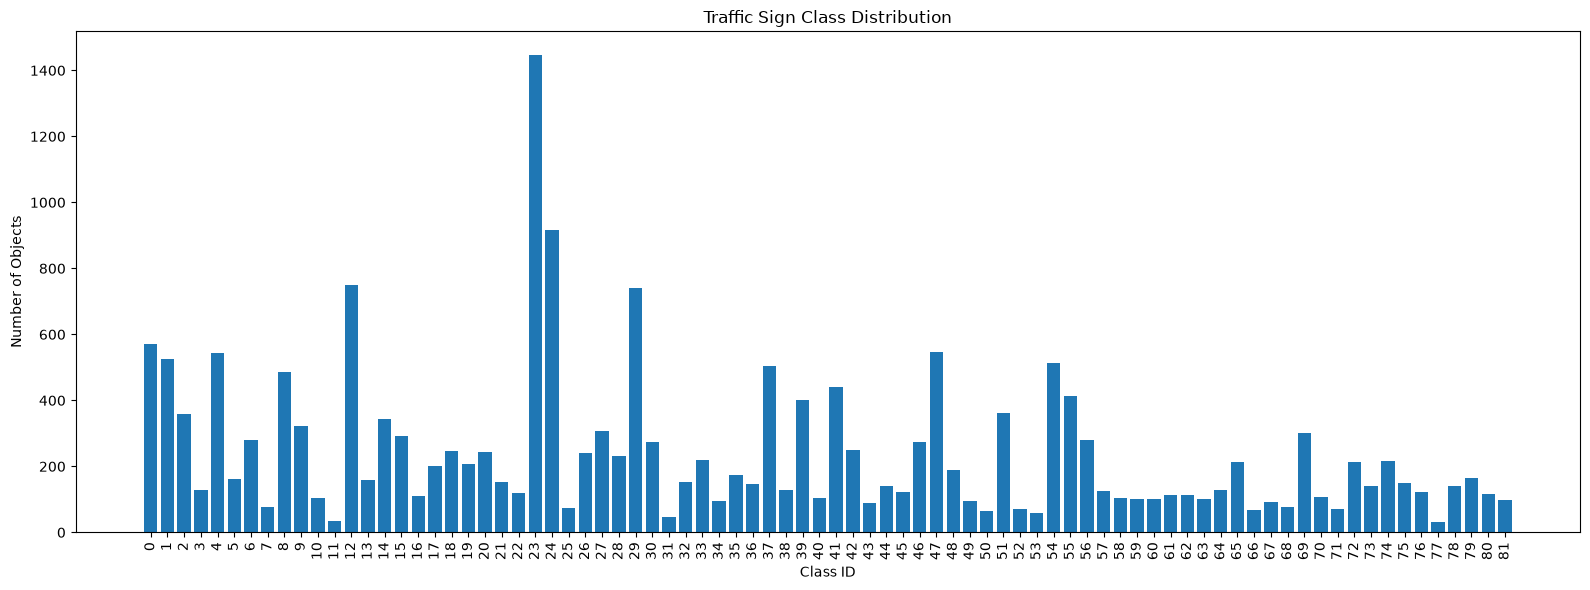

In [21]:
plt.figure(figsize=(16, 6))

plt.bar(
    class_counts.index.astype(str),
    class_counts.values
)

plt.title("Traffic Sign Class Distribution")
plt.xlabel("Class ID")
plt.ylabel("Number of Objects")

plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

In [22]:
print("Most common classes:")
display(class_counts.sort_values(ascending=False).head(10))

print("Least common classes:")
display(class_counts.sort_values().head(10))

Most common classes:


class_id
23    1446
24     915
12     750
29     741
0      572
47     546
4      543
1      524
54     512
37     504
Name: count, dtype: int64

Least common classes:


class_id
77    32
11    35
31    46
53    60
50    65
66    67
52    71
71    72
25    75
68    78
Name: count, dtype: int64

→ Dataset có class imbalance.

# 2. Bounding Box Analysis

YOLO label có:

class_id x_center y_center width height

Trong đó width, height được chuẩn hóa từ 0 → 1.

In [23]:
labels_df["bbox_area"] = (
    labels_df["width"] * labels_df["height"]
)

display(
    labels_df[
        ["class_id", "width", "height", "bbox_area"]
    ].head()
)

,class_id,width,height,bbox_area
0,54,0.011260,0.015344,0.000173
1,24,0.017500,0.016417,0.000287
2,24,0.018615,0.018875,0.000351
3,54,0.012115,0.015344,0.000186
4,24,0.019677,0.020208,0.000398


In [24]:
labels_df[["width", "height", "bbox_area"]].describe()

,width,height,bbox_area
count,19748.000000,19748.000000,19748.000000
mean,0.087599,0.106448,0.024640
std,0.119192,0.139809,0.080245
min,0.003606,0.002404,0.000009
25%,0.025164,0.028000,0.000730
50%,0.048331,0.056281,0.002762
75%,0.097000,0.118750,0.011728
max,0.939904,0.995192,0.858567


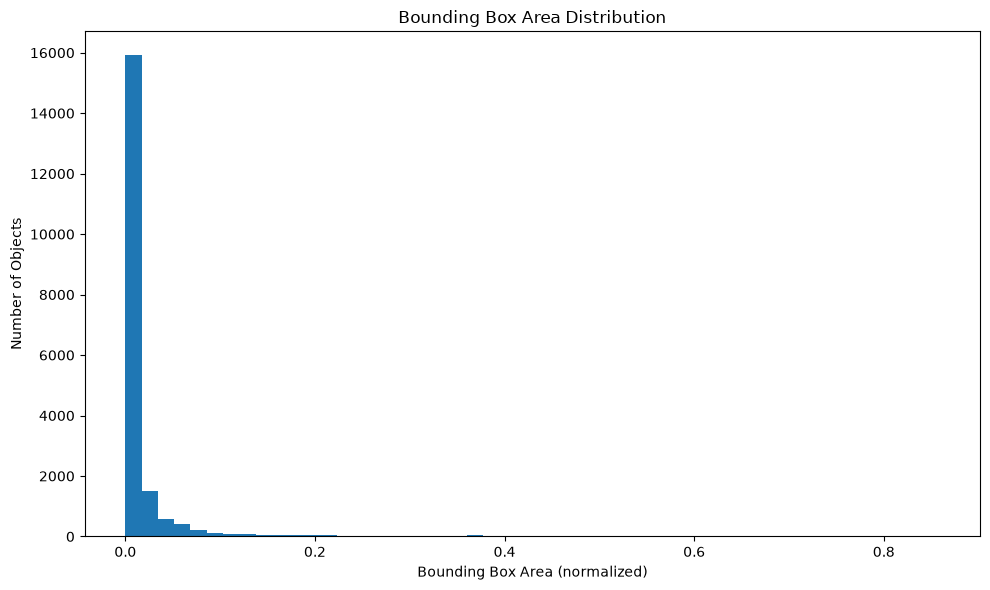

In [26]:
plt.figure(figsize=(10, 6))

plt.hist(
    labels_df["bbox_area"],
    bins=50
)

plt.title("Bounding Box Area Distribution")
plt.xlabel("Bounding Box Area (normalized)")
plt.ylabel("Number of Objects")

plt.tight_layout()
plt.show()

# 3. Small Object Analysis

In [27]:
def classify_object_size(area):
    if area < 0.01:
        return "Very Small"
    elif area < 0.05:
        return "Small"
    elif area < 0.20:
        return "Medium"
    else:
        return "Large"


labels_df["object_size"] = labels_df["bbox_area"].apply(
    classify_object_size
)

display(
    labels_df["object_size"].value_counts()
)

object_size
Very Small    14351
Small          3618
Medium         1154
Large           625
Name: count, dtype: int64

In [28]:
size_distribution = (
    labels_df["object_size"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

display(size_distribution)

object_size
Very Small    72.67
Small         18.32
Medium         5.84
Large          3.16
Name: proportion, dtype: float64

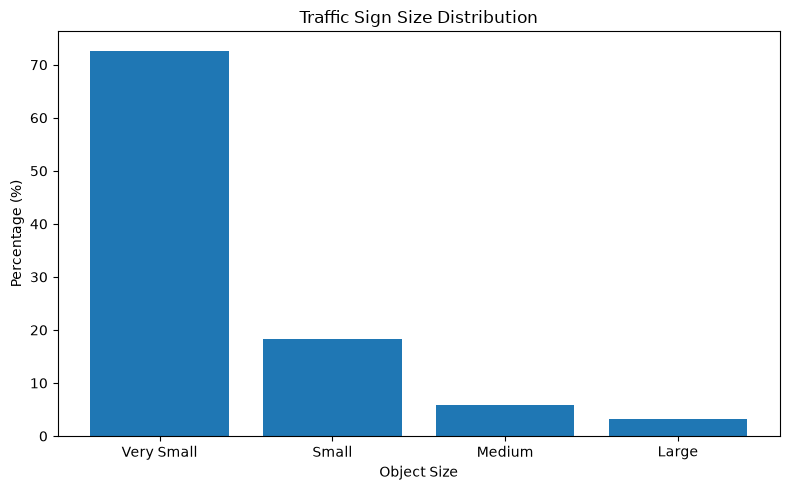

In [30]:
plt.figure(figsize=(8, 5))

plt.bar(
    size_distribution.index,
    size_distribution.values
)

plt.title("Traffic Sign Size Distribution")
plt.xlabel("Object Size")
plt.ylabel("Percentage (%)")

plt.tight_layout()
plt.show()

# 4. Visual Inspection

In [31]:
import cv2

In [32]:
sample_split = "train"

image_dir = SPLITS[sample_split] / "images"
label_dir = SPLITS[sample_split] / "labels"

image_files = list(image_dir.glob("*"))

sample_image = image_files[0]
sample_label = label_dir / f"{sample_image.stem}.txt"

print("Image:", sample_image)
print("Label:", sample_label)

Image: d:\FPT\Semester 4\DAP391m\Vietnamese traffic sign recognization\dataset\dataset\train\images\0002.jpg
Label: d:\FPT\Semester 4\DAP391m\Vietnamese traffic sign recognization\dataset\dataset\train\labels\0002.txt


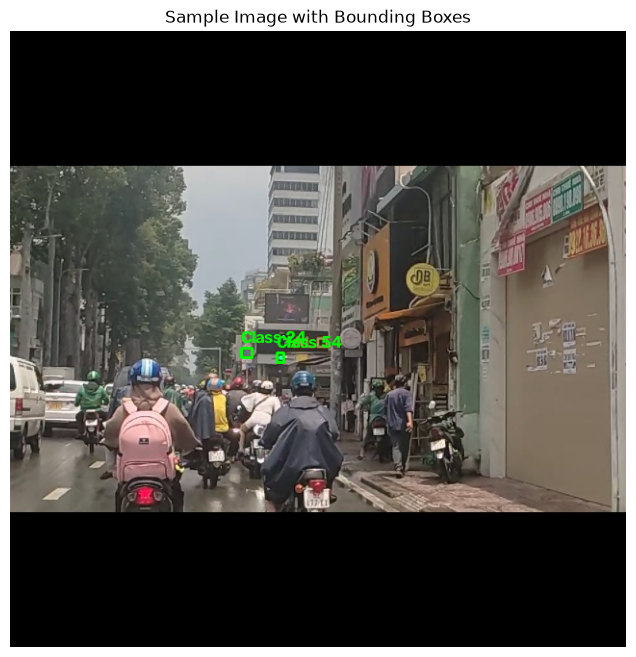

In [33]:
image = cv2.imread(str(sample_image))

height, width = image.shape[:2]

with open(sample_label, "r", encoding="utf-8") as f:
    for line in f:
        values = line.strip().split()

        if not values:
            continue

        class_id = int(values[0])

        x_center = float(values[1]) * width
        y_center = float(values[2]) * height
        box_width = float(values[3]) * width
        box_height = float(values[4]) * height

        x1 = int(x_center - box_width / 2)
        y1 = int(y_center - box_height / 2)
        x2 = int(x_center + box_width / 2)
        y2 = int(y_center + box_height / 2)

        cv2.rectangle(
            image,
            (x1, y1),
            (x2, y2),
            (0, 255, 0),
            2
        )

        cv2.putText(
            image,
            f"Class {class_id}",
            (x1, max(y1 - 5, 0)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2
        )

image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))
plt.imshow(image_rgb)
plt.axis("off")
plt.title("Sample Image with Bounding Boxes")
plt.show()

# EDA Conclusions

## 1. Class Distribution
The dataset contains multiple traffic sign classes with noticeable class imbalance.
Some classes have significantly more objects than others.

## 2. Bounding Box Analysis
Bounding box analysis shows the distribution of traffic sign sizes in the images.
The dataset contains objects with different scales.

## 3. Small Object Analysis
A considerable number of traffic signs may appear as small objects.
This can make detection more challenging, especially for distant signs.

## 4. Visual Inspection
Visual inspection is used to verify bounding box quality, image diversity,
occlusion, background complexity, and traffic sign visibility.

## 5. Implications for Preprocessing
The EDA results indicate that preprocessing and augmentation should pay attention to:

- Class imbalance
- Small traffic signs
- Different object scales
- Complex backgrounds
- Occlusion and different viewing angles

These findings will be considered in the preprocessing and YOLO training stages.